# Product Recommendation with Collaborative Filtering

### "Customers who bought this also bought…"

**Collaborative filtering (CF)** powers the classic e-commerce widget. It works purely from the **customer×product purchase matrix** — no product descriptions or categories needed, just "who bought what".


In [40]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Rows = customers, columns = products. 1 = bought, 0 = not bought
purchases = pd.DataFrame({
    'Mouse':      [1, 1, 1, 0, 0, 1, 0, 1, 0, 1],
    'Keyboard':   [1, 1, 1, 0, 0, 1, 0, 1, 0, 0],
    'Monitor':    [1, 1, 0, 1, 0, 1, 0, 0, 1, 0],
    'Headphones': [0, 1, 0, 1, 1, 1, 1, 0, 1, 1],
    'Microphone': [0, 0, 0, 1, 1, 1, 1, 0, 1, 0],
}, index=['Alice', 'Bob', 'Charlie', 'David', 'Eve',
          'Frank', 'Grace', 'Henry', 'Ivy', 'Jack'])

purchases

,Mouse,Keyboard,Monitor,Headphones,Microphone
Alice,1,1,1,0,0
Bob,1,1,1,1,0
Charlie,1,1,0,0,0
David,0,0,1,1,1
Eve,0,0,0,1,1
Frank,1,1,1,1,1
Grace,0,0,0,1,1
Henry,1,1,0,0,0
Ivy,0,0,1,1,1
Jack,1,0,0,1,0


## 1. Product similarity

Two products are *similar* if the same customers tend to buy both. We measure this with **cosine similarity** between the products' purchase columns (hence `purchases.T` — we compare columns, not rows). The result is a product×product matrix where `1.0` = bought by exactly the same set of customers.

In [35]:
product_similarity = cosine_similarity(purchases.T)
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=purchases.columns,
    columns=purchases.columns,
)

product_similarity_df.round(2)

,Mouse,Keyboard,Monitor,Headphones,Microphone
Mouse,1.00,0.91,0.55,0.46,0.18
Keyboard,0.91,1.00,0.60,0.34,0.20
Monitor,0.55,0.60,1.00,0.68,0.60
Headphones,0.46,0.34,0.68,1.00,0.85
Microphone,0.18,0.20,0.60,0.85,1.00


### Visualize the clusters

A similarity table is easier to read as a **heatmap**. Reordering the products by hierarchical clustering puts similar ones side by side, so the co-purchase groups appear as **bright blocks along the diagonal** — peripherals in one block, audio/streaming gear in another.

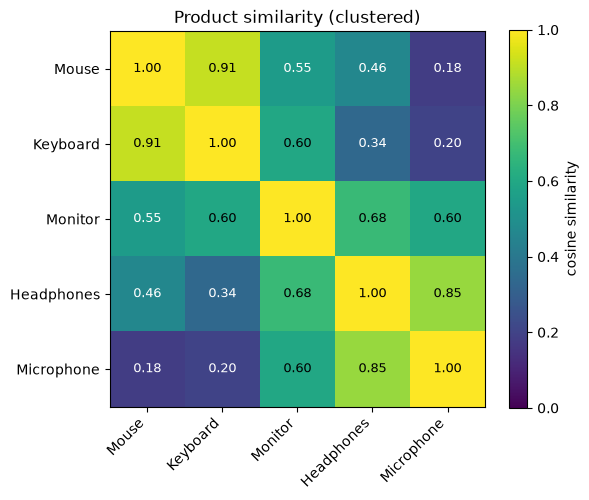

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Reorder products by hierarchical clustering so similar ones sit next to each
# other — the co-purchase groups then show up as bright blocks on the diagonal.
dist = 1 - product_similarity_df.values
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2                      # enforce a clean symmetric distance
order = leaves_list(linkage(squareform(dist, checks=False), method="average"))
ordered = product_similarity_df.iloc[order, order]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ordered, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(len(ordered)))
ax.set_yticks(range(len(ordered)))
ax.set_xticklabels(ordered.columns, rotation=45, ha="right")
ax.set_yticklabels(ordered.index)

# Annotate each cell with its similarity value
for i in range(len(ordered)):
    for j in range(len(ordered)):
        val = ordered.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val < 0.6 else "black", fontsize=9)

ax.set_title("Product similarity (clustered)")
fig.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout()
plt.show()

## 2. "Customers who bought this also bought…"

This is the headline feature, and it falls straight out of the similarity matrix: given a product, return the other products most similar to it. No customer context needed — it's purely product-to-product, which is why stores can precompute it and show it on every product page.

In [41]:
def also_bought(product, n=3):
    """Products most often bought by the same customers as `product`."""
    sims = product_similarity_df[product].drop(product)
    return sims.sort_values(ascending=False).head(n).round(3)


print("Customers who bought a Keyboard also bought:")
also_bought('Keyboard')

Customers who bought a Keyboard also bought:


Mouse         0.913
Monitor       0.600
Headphones    0.338
Name: Keyboard, dtype: float64

## 3. Recommend products to a customer

Wrap the logic in a function, score every product the customer hasn't bought, and return the highest-scoring ones — a personalised "recommended for you" row.

In [42]:
def match_score(customer, product):
    """Item-based score: how well `product` matches what `customer` already bought."""
    customer_purchases = purchases.loc[customer]
    bought = customer_purchases[customer_purchases > 0]
    sims = product_similarity_df.loc[product, bought.index]
    return sims.sum()


def recommend(customer, n=3):
    """Top-n not-yet-bought products for a customer, ranked by match score."""
    customer_purchases = purchases.loc[customer]
    not_bought = customer_purchases[customer_purchases == 0].index
    scores = {product: match_score(customer, product) for product in not_bought}
    return pd.Series(scores).sort_values(ascending=False).head(n).round(3)


target = 'Alice'
print(f"{target} already bought:", list(purchases.loc[target][purchases.loc[target] > 0].index))
print(f"\nRecommended for {target}:")
recommend(target)

Alice already bought: ['Mouse', 'Keyboard', 'Monitor']

Recommended for Alice:


Headphones    1.477
Microphone    0.983
dtype: float64